epoch    0  loss=1.7369
epoch 1000  loss=1.5787
epoch 2000  loss=1.5326
epoch 3000  loss=1.3748
epoch 4000  loss=1.4172
epoch 5000  loss=1.4935
sample stats: min [-1.2080065 -0.646175 ] max [2.0944142 1.1349591] mean [0.49358997 0.10419133]
Saved score_based_generation.png


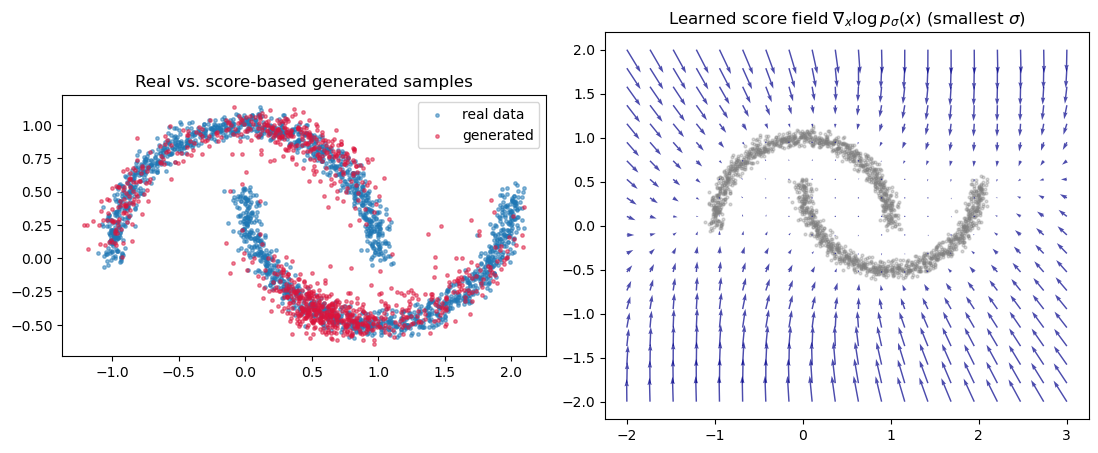

In [1]:
"""
Score-based generative model on a 2D toy dataset (two moons), fully runnable
without any external data download. Trains a small MLP score network via
denoising score matching, samples via annealed Langevin dynamics, and plots
true data vs. generated samples plus the learned score (vector) field.
"""

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"


# ----------------------------- Toy dataset: two moons -----------------------------
def sample_moons(n):
    t = np.linspace(0, np.pi, n // 2)
    x1 = np.stack([np.cos(t), np.sin(t)], axis=1)
    x2 = np.stack([1 - np.cos(t), 1 - np.sin(t) - 0.5], axis=1)
    x = np.concatenate([x1, x2], axis=0)
    x += np.random.randn(*x.shape) * 0.05
    return torch.tensor(x, dtype=torch.float32)


# ----------------------------- Score network (MLP) -----------------------------
class ScoreNet(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.SiLU(),   # (x, y, log-sigma)
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x, sigma):
        log_sigma = torch.log(sigma).view(-1, 1)
        inp = torch.cat([x, log_sigma], dim=1)
        return self.net(inp)


# ----------------------------- Score matching + Langevin sampling -----------------------------
class ScoreBasedModel:
    def __init__(self, sigmas, device=device):
        self.sigmas = sigmas.to(device)

    def loss(self, model, x0):
        idx = torch.randint(0, len(self.sigmas), (x0.size(0),), device=x0.device)
        sigma = self.sigmas[idx].view(-1, 1)
        noise = torch.randn_like(x0)
        x_noisy = x0 + sigma * noise
        target_score = -noise / sigma
        pred_score = model(x_noisy, self.sigmas[idx])
        loss = ((pred_score - target_score) ** 2).sum(dim=1) * sigma.view(-1) ** 2
        return loss.mean()

    @torch.no_grad()
    def sample(self, model, n_samples, n_steps_per_sigma=100, step_lr=1e-1, clip_score=None, device=device):
        x = torch.randn(n_samples, 2, device=device) * 1.5  # start spread out
        for sigma in self.sigmas:
            alpha = step_lr * (sigma / self.sigmas[-1]) ** 2
            for _ in range(n_steps_per_sigma):
                score = model(x, sigma.expand(n_samples))
                if clip_score is not None:
                    score = score.clamp(-clip_score, clip_score)
                noise = torch.randn_like(x)
                x = x + 0.5 * alpha * score + torch.sqrt(alpha) * noise
                if not torch.isfinite(x).all():
                    raise RuntimeError(f"sampling diverged at sigma={sigma.item():.4f}")
        return x


# ----------------------------- Train -----------------------------
data = sample_moons(2000).to(device)
model = ScoreNet().to(device)
opt = torch.optim.Adam(model.parameters(), lr=1e-3)

sigmas = torch.exp(torch.linspace(np.log(1.0), np.log(0.01), 10))
sbm = ScoreBasedModel(sigmas, device=device)

n_epochs = 6000
batch_size = 256
opt_sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
for epoch in range(n_epochs):
    idx = torch.randint(0, data.size(0), (batch_size,))
    x0 = data[idx]
    loss = sbm.loss(model, x0)
    opt.zero_grad()
    loss.backward()
    opt.step()
    opt_sched.step()
    if epoch % 1000 == 0:
        print(f"epoch {epoch:4d}  loss={loss.item():.4f}")

# ----------------------------- Sample -----------------------------
model.eval()
samples = sbm.sample(model, n_samples=1000, n_steps_per_sigma=100, step_lr=2e-3, clip_score=50.0, device=device)
samples = samples.cpu().numpy()
data_np = data.cpu().numpy()
print("sample stats: min", samples.min(0), "max", samples.max(0), "mean", samples.mean(0))

# ----------------------------- Visualize -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(data_np[:, 0], data_np[:, 1], s=6, alpha=0.5, label="real data")
axes[0].scatter(samples[:, 0], samples[:, 1], s=6, alpha=0.5, color="crimson", label="generated")
axes[0].set_title("Real vs. score-based generated samples")
axes[0].legend()
axes[0].set_aspect("equal")

# score (vector) field at the smallest sigma, overlaid with real data
with torch.no_grad():
    grid_x, grid_y = np.meshgrid(np.linspace(-2, 3, 20), np.linspace(-2, 2, 20))
    grid = torch.tensor(np.stack([grid_x.ravel(), grid_y.ravel()], axis=1), dtype=torch.float32, device=device)
    sigma_small = sigmas[-1].expand(grid.size(0)).to(device)
    scores = model(grid, sigma_small).cpu().numpy()

axes[1].scatter(data_np[:, 0], data_np[:, 1], s=4, alpha=0.3, color="gray")
axes[1].quiver(grid_x, grid_y, scores[:, 0].reshape(grid_x.shape), scores[:, 1].reshape(grid_x.shape),
               color="darkblue", alpha=0.7)
axes[1].set_title(r"Learned score field $\nabla_x \log p_\sigma(x)$ (smallest $\sigma$)")
axes[1].set_aspect("equal")

plt.tight_layout()
plt.savefig("score_based_generation.png", dpi=130)
print("Saved score_based_generation.png")